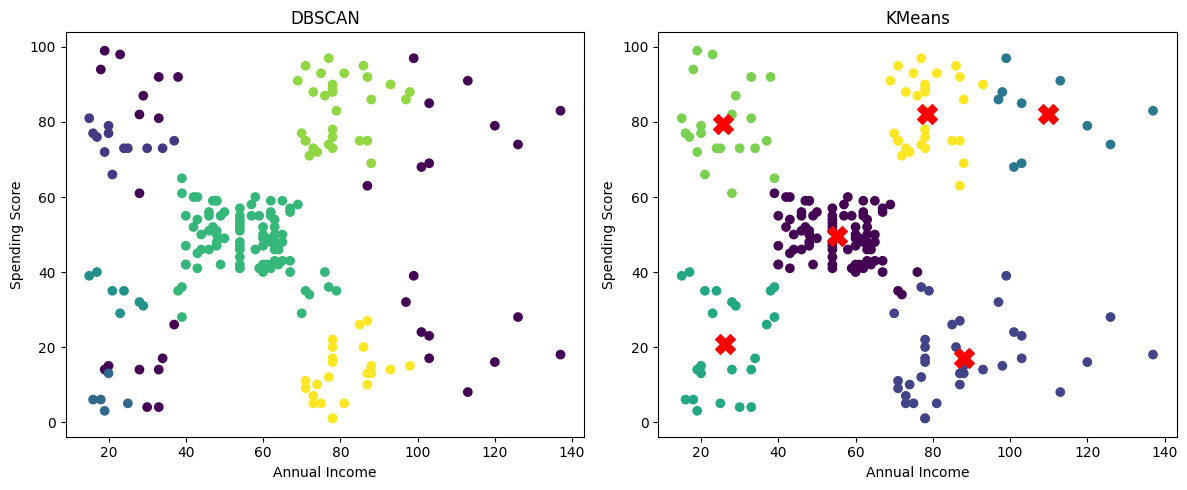

In [1]:
# Compare DBSCAN and K-Means on the same dataset.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans

data = pd.read_csv("Mall_Customers.csv")

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

db = DBSCAN(eps=8,min_samples=5)

db_labels = db.fit_predict(X)

clusters = len(set(db_labels))-(1 if -1 in db_labels else 0)

kmeans = KMeans(
    n_clusters=clusters,
    random_state=42,
    n_init=10
)

km_labels = kmeans.fit_predict(X)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=db_labels
)

plt.title("DBSCAN")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.subplot(1,2,2)

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=km_labels
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=200,
    color='red'
)

plt.title("KMeans")

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.tight_layout()

plt.show()